<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 07</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Model training</div><div style="font-size:1.05em;opacity:0.85">Three supervised rungs, tuned without ever looking at the test cutoff.</div></div>

Stage 06 set the bar: rank at least as well as BG/NBD *and* stay calibrated across seasons.
This stage trains the supervised rungs of the ladder on the ten training cutoffs: a
**logistic regression**, **LightGBM** on the customer features, and **LightGBM + season**, the
same model with the cutoff-month features of stage 05. Each is tuned with Optuna on
rolling-origin folds that respect time, and every run is tracked in MLflow.

**Pipeline rule.** `churnvalue train` does the work and writes `models/` (fitted models plus
`training.json`) and one MLflow run per model; this notebook only reads them. Nothing is fitted
here.

| | |
|---|---|
| **Input** | `data/interim/snapshots.parquet` · `models/training.json` · `models/*.joblib` · MLflow (`mlflow.db`) |
| **Outputs** | `reports/results/07_summary.json` · `reports/figures/07_*.png` |
| **Parameters** | `configs/default.yaml` → `training` (40 Optuna trials, seed 42, ≥ 3 fit cutoffs per fold), `tracking` |
| **Shared code** | `churnvalue.models` · `churnvalue.training` · `churnvalue.splits` · `churnvalue.tracking` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">M1 the rungs</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">M2 folds</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">M3 logistic regression</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">M4 Optuna</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">M5 fold results</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">M6 MLflow</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from churnvalue.config import load_config, project_root
from churnvalue.evaluate import temporal_split
from churnvalue.models import SUPERVISED
from churnvalue.reporting import StageSummary
from churnvalue.splits import rolling_origin_folds
from churnvalue.tracking import export_experiments
from churnvalue.training import load_estimator, load_training
from churnvalue.viz import style
from churnvalue.viz.style import INK, MODEL_COLORS, MODEL_LABELS, MUTED, NEUTRAL, RETAINED

os.chdir(project_root())
CFG = load_config()
H = CFG.snapshots.horizon_days
STAGE, FIGURES, RESULTS = "07", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


snapshots = pd.read_parquet(CFG.data.interim_dir / "snapshots.parquet")
split = temporal_split(snapshots, CFG)
folds = rolling_origin_folds(split.train, H, CFG.training.min_train_cutoffs)
training = load_training(CFG.models_dir)
train_rows = snapshots[snapshots["cutoff"].isin(split.train)]

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">M1 · The rungs</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">same rows, three model classes, one difference in inputs</span></div>

All three models learn from the same rows: every eligible customer at each of the ten training
cutoffs, labelled by whether they bought in the following 90 days. They differ in model class
and in one group of inputs — the two cutoff-month features. The plain LightGBM is kept on
purpose: it is the ablation that shows what the season features buy (stage 11).

In [2]:
rungs = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS[name],
            "class": "logistic regression" if spec.kind == "logreg" else "gradient boosting",
            "inputs": len(spec.features),
            "cutoff month": "yes" if "cutoff_month_sin" in spec.features else "no",
            "CV log loss": training[name]["cv_log_loss"],
        }
        for name, spec in SUPERVISED.items()
    ]
).set_index("model")
S["n_train_rows"] = len(train_rows)
S["n_train_cutoffs"] = len(split.train)
S["train_churn_rate"] = train_rows["churn"].mean()
S["n_features"] = {name: len(spec.features) for name, spec in SUPERVISED.items()}
display(rungs.style.format({"CV log loss": "{:.4f}"}))
print(
    f"{S['n_train_rows']:,} training rows from {S['n_train_cutoffs']} cutoffs, "
    f"churn rate {S['train_churn_rate']:.1%}"
)

,class,inputs,cutoff month,CV log loss
model,,,,
logistic regression,logistic regression,19,yes,0.6596
LightGBM,gradient boosting,17,no,0.6774
LightGBM + season,gradient boosting,19,yes,0.6741


17,283 training rows from 10 cutoffs, churn rate 39.4%


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">M2 · Folds</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">tune on the past, validate on a later month</span></div>

A random split would let a model see the same customer's future while it learns their past.
Rolling-origin folds avoid it: each fold validates on one training cutoff and fits only on
earlier cutoffs whose **label window has closed** by then, so no fit label overlaps the
validation window. Folds need at least three fit cutoffs, which leaves five folds, validated
from November 2010 to March 2011. The final model is refitted on all ten cutoffs; the
calibration and test cutoffs are never touched here.

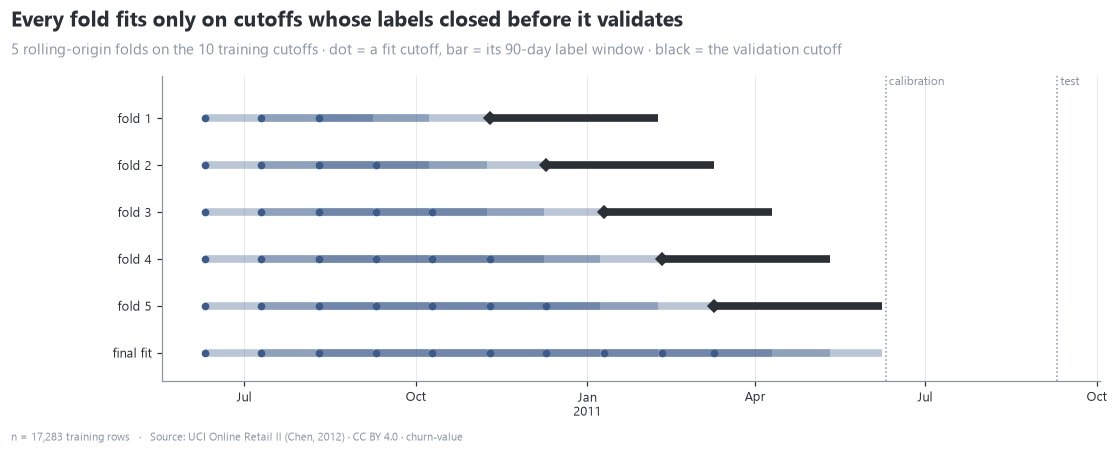

In [3]:
S["n_folds"] = len(folds)
S["fold_validation_cutoffs"] = [v for _, v in folds]
fig, ax = plt.subplots(figsize=(11, 3.6))
rows = [(f"fold {i + 1}", fit, val) for i, (fit, val) in enumerate(folds)]
rows.append(("final fit", split.train, None))
for y, (_, fit, validation) in enumerate(reversed(rows)):
    for c in fit:
        ax.plot(
            [c, c + pd.Timedelta(days=H)],
            [y, y],
            color=NEUTRAL,
            lw=5,
            alpha=0.35,
            solid_capstyle="butt",
        )
        ax.plot(c, y, "o", color=NEUTRAL, markersize=4)
    if validation is not None:
        ax.plot(
            [validation, validation + pd.Timedelta(days=H)],
            [y, y],
            color=INK,
            lw=5,
            solid_capstyle="butt",
        )
        ax.plot(validation, y, "D", color=INK, markersize=6)
for c, name in [(split.calibration, "calibration"), (split.test, "test")]:
    ax.axvline(c, color=MUTED, lw=1, ls=":")
    ax.text(c, len(rows) - 0.35, f" {name}", color=MUTED, fontsize=8, va="bottom")
ax.set_yticks(range(len(rows)), [r[0] for r in reversed(rows)])
ax.set_ylim(-0.6, len(rows) - 0.1)
ax.grid(axis="y", visible=False)
style.date_axis(ax)
style.headline(
    fig,
    "Every fold fits only on cutoffs whose labels closed before it validates",
    f"{len(folds)} rolling-origin folds on the {len(split.train)} training cutoffs · dot = a fit "
    "cutoff, bar = its 90-day label window · black = the validation cutoff",
)
style.add_source(fig, f"n = {len(train_rows):,} training rows")
save(fig, "folds")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">M3 · Logistic regression</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">a transparent rung, heavily regularised</span></div>

The logistic regression sees `log1p` of the heavy-tailed features, standardised, with an L2
penalty whose strength Optuna chose. Its coefficients are readable as the change in churn
log-odds per standard deviation of the (log) feature. Tuning picked a strong penalty, so the
coefficients are small; their signs say more than their sizes.

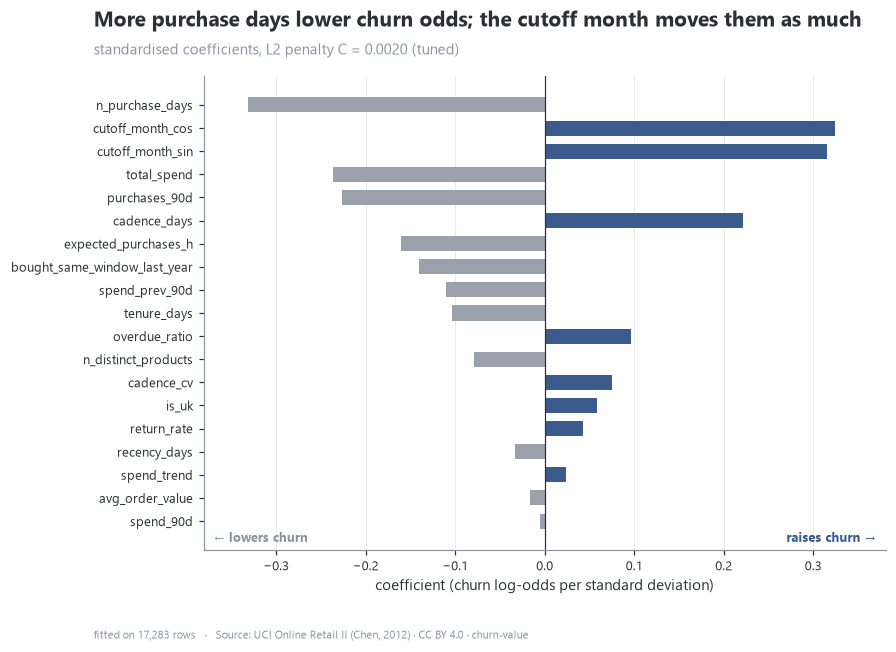

In [4]:
logreg = load_estimator(CFG.models_dir, "logreg")
coef = pd.Series(
    logreg.named_steps["model"].coef_[0], index=list(SUPERVISED["logreg"].features)
).sort_values(key=np.abs)
S["logreg_C"] = training["logreg"]["params"]["C"]
S["logreg_top_coefficients"] = coef.iloc[::-1].head(5).to_dict()
fig, ax = plt.subplots(figsize=(8, 5.6))
ax.barh(
    coef.index,
    coef.values,
    color=[NEUTRAL if v > 0 else RETAINED for v in coef.values],
    height=0.65,
)
ax.axvline(0, color=INK, lw=0.8)
ax.grid(axis="y", visible=False)
ax.set_xlabel("coefficient (churn log-odds per standard deviation)")
lim = np.abs(coef).max() * 1.15
ax.set_xlim(-lim, lim)
ax.text(
    lim * 0.97, -0.9, "raises churn →", ha="right", fontsize=8.5, color=NEUTRAL, fontweight="bold"
)
ax.text(
    -lim * 0.97, -0.9, "← lowers churn", ha="left", fontsize=8.5, color=MUTED, fontweight="bold"
)
style.headline(
    fig,
    "More purchase days lower churn odds; the cutoff month moves them as much",
    f"standardised coefficients, L2 penalty C = {S['logreg_C']:.4f} (tuned)",
)
style.add_source(fig, f"fitted on {len(train_rows):,} rows")
save(fig, "logreg")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">M4 · Optuna</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">forty trials per model, scored by fold log loss</span></div>

Each trial proposes hyper-parameters (tree size, learning rate, row and column sampling, L2),
fits the model on every fold and returns the **mean validation log loss**. Log loss is a proper
scoring rule: it rewards a model for ranking customers well *and* for putting its probabilities
at the right level, which is what the economics need. The sampler (TPE) is seeded, so the
search is reproducible.

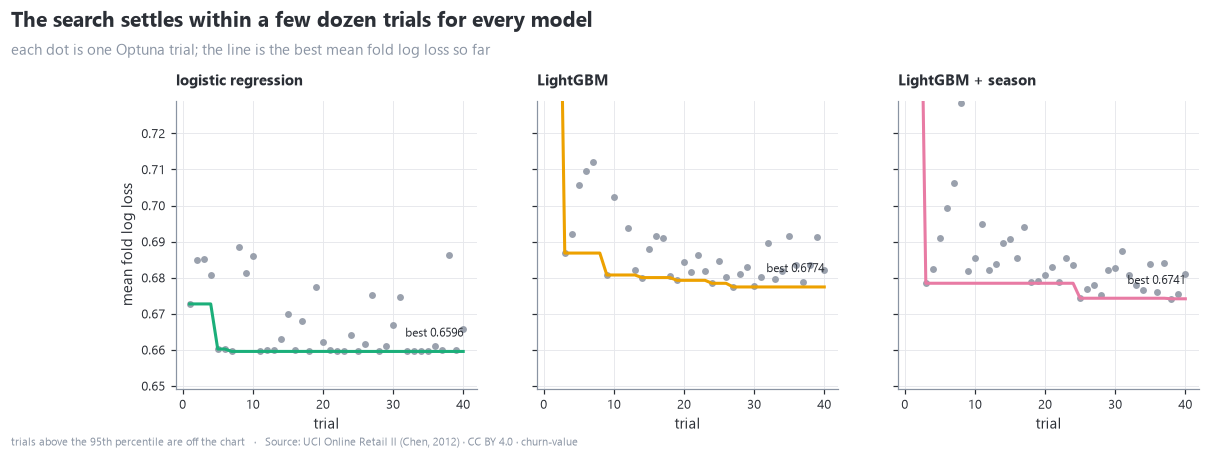

,C,n_estimators,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,reg_lambda
logistic regression,0.0020,—,—,—,—,—,—,—
LightGBM,—,300.0000,0.0106,5.0000,60.0000,0.7717,0.4017,13.8631
LightGBM + season,—,200.0000,0.0136,14.0000,43.0000,0.7894,0.4976,23.8208


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (name, record) in zip(axes, training.items(), strict=True):
    values = np.array(record["trial_values"])
    trials = np.arange(1, values.size + 1)
    ax.plot(trials, values, "o", color=RETAINED, markersize=3.5)
    ax.plot(trials, np.minimum.accumulate(values), color=MODEL_COLORS[name], lw=2)
    ax.set_title(MODEL_LABELS[name], fontsize=9.5)
    ax.set_xlabel("trial")
    ax.annotate(
        f"best {values.min():.4f}",
        (values.size, values.min()),
        xytext=(0, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=8,
        color=INK,
    )
axes[0].set_ylabel("mean fold log loss")
axes[0].set_ylim(
    None, np.percentile(np.concatenate([r["trial_values"] for r in training.values()]), 95)
)
S["n_trials"] = len(training["lightgbm"]["trial_values"])
style.headline(
    fig,
    "The search settles within a few dozen trials for every model",
    "each dot is one Optuna trial; the line is the best mean fold log loss so far",
)
style.add_source(fig, "trials above the 95th percentile are off the chart")
save(fig, "optuna")
plt.show()

params = pd.DataFrame({MODEL_LABELS[n]: training[n]["params"] for n in training}).T
display(params.style.format(precision=4, na_rep="—"))
S["seasonal_params"] = training["lightgbm_seasonal"]["params"]

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">M5 · Fold results</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">every model under-predicts churn in the folds</span></div>

Fold by fold, the models rank customers similarly (ROC-AUC between 0.73 and 0.80), and the
ranking improves as more history becomes available for fitting. The level of the predictions
tells a different story: **both LightGBM models predict less churn than happened in every
fold**, and the logistic regression starts far below and ends above. The folds fit on summer
and autumn 2010 and validate on winter, when churn peaks; the cutoff-month features cannot help
with a month the model has never seen, and here no fold has seen its validation month. The
logistic regression wins on fold log loss largely because its level drifts upwards across the
folds. Whether the season features work is tested where they can work: on the later cutoffs
of stage 08, whose months the final fit has seen.

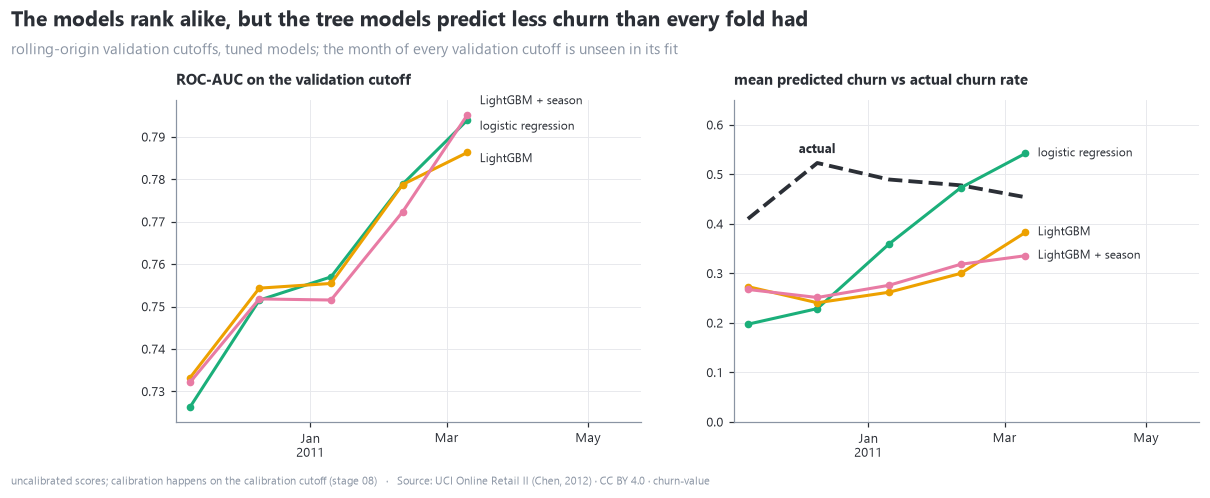

In [6]:
fold_frames = []
for name, record in training.items():
    frame = pd.DataFrame(record["folds"])
    frame["model"] = name
    fold_frames.append(frame)
fold_df = pd.concat(fold_frames, ignore_index=True)
fold_df["validation_cutoff"] = pd.to_datetime(fold_df["validation_cutoff"])
fold_df["gap"] = fold_df["mean_score"] - fold_df["churn_rate"]
S["fold_roc_range"] = [fold_df["roc_auc"].min(), fold_df["roc_auc"].max()]
S["fold_gap_by_model"] = fold_df.groupby("model")["gap"].agg(["min", "max"]).to_dict("index")
S["cv_log_loss"] = {name: record["cv_log_loss"] for name, record in training.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
last = fold_df["validation_cutoff"].max()
for name in training:
    part = fold_df[fold_df["model"] == name]
    ax.plot(
        part["validation_cutoff"], part["roc_auc"], "o-", color=MODEL_COLORS[name], markersize=4
    )
ends = fold_df[fold_df["validation_cutoff"] == last].set_index("model")["roc_auc"]
style.direct_labels(ax, last + pd.Timedelta(days=4), ends.to_dict(), MODEL_LABELS, 0.006)
ax.set_title("ROC-AUC on the validation cutoff", fontsize=9.5)
ax.set_xlim(None, fold_df["validation_cutoff"].max() + pd.Timedelta(days=75))
style.date_axis(ax, months=(1, 3, 5, 7, 9, 11))
ax = axes[1]
actual = fold_df.drop_duplicates("validation_cutoff")
ax.plot(actual["validation_cutoff"], actual["churn_rate"], color=INK, lw=2.5, ls="--")
ax.text(
    actual["validation_cutoff"].iloc[1],
    actual["churn_rate"].iloc[1] + 0.02,
    "actual",
    fontsize=8.5,
    color=INK,
    fontweight="bold",
    ha="center",
)
for name in training:
    part = fold_df[fold_df["model"] == name]
    ax.plot(
        part["validation_cutoff"], part["mean_score"], "o-", color=MODEL_COLORS[name], markersize=4
    )
ends = fold_df[fold_df["validation_cutoff"] == last].set_index("model")["mean_score"]
style.direct_labels(ax, last + pd.Timedelta(days=4), ends.to_dict(), MODEL_LABELS, 0.035)
ax.set_title("mean predicted churn vs actual churn rate", fontsize=9.5)
ax.set_ylim(0, 0.65)
ax.set_xlim(None, last + pd.Timedelta(days=75))
style.date_axis(ax, months=(1, 3, 5, 7, 9, 11))
style.headline(
    fig,
    "The models rank alike, but the tree models predict less churn than every fold had",
    "rolling-origin validation cutoffs, tuned models; "
    "the month of every validation cutoff is unseen in its fit",
)
style.add_source(
    fig, "uncalibrated scores; calibration happens on the calibration cutoff (stage 08)"
)
save(fig, "folds_results")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">M6 · MLflow</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">every run recorded, and exported for the site</span></div>

`churnvalue train` logs one MLflow run per model — parameters, the CV folds, the full Optuna
history — tagged with the git commit, the configuration hash and the dataset checksum.
`churnvalue evaluate` later adds the test metrics to the same run. Visitors of the site never
run MLflow, so `churnvalue export` turns the experiment into `experiments.json`.

In [7]:
experiments = export_experiments(CFG.tracking)
runs = pd.DataFrame(
    [
        {
            "model": run["model"],
            "run": run["run_id"][:8],
            "started (UTC)": run["started_at"][:16].replace("T", " "),
            "CV log loss": run["metrics"].get("cv_log_loss"),
            "test ROC-AUC": run["metrics"].get("test_roc_auc"),
            "test realized profit": run["metrics"].get("test_realized_profit"),
        }
        for run in experiments["runs"]
    ]
)
S["n_mlflow_runs"] = len(runs)
display(
    runs.head(6).style.format(
        {"CV log loss": "{:.4f}", "test ROC-AUC": "{:.3f}", "test realized profit": "£{:,.0f}"},
        na_rep="—",
    )
)

,model,run,started (UTC),CV log loss,test ROC-AUC,test realized profit
0,lightgbm_seasonal,93094a53,2026-09-27 01:47,0.6741,0.766,"£23,139"
1,lightgbm,eb99a381,2026-09-27 01:46,0.6774,0.771,"£14,972"
2,logreg,97904332,2026-09-27 01:45,0.6596,0.761,"£8,089"


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">07 → 08, 09, 11</span></div>

**Produced** — `reports/results/07_summary.json` and the figures `07_folds`, `07_logreg`,
`07_optuna`, `07_folds_results`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>Rolling-origin validation cannot test the season features: no fold has seen its validation month, and both LightGBM models under-predict churn in every fold. Fold log loss favours the logistic regression, whose level happens to drift upwards across the folds.</li><li>Ranking quality is similar across the three rungs and improves as the fit window grows.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>Hyper-parameters are fixed by the fold log loss, before any look at the calibration or test cutoff. The deployed model is fixed in advance as <b>LightGBM + season</b> (ADR 0005), the rung the browser what-if can run as ONNX; the numbers of stage 08 decide nothing retroactively.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>08_evaluation</b> — calibration on the calibration cutoff and the test verdict, with CIs, on cutoffs whose month the final fit has seen.</li><li><b>09_explainability</b> — why the tree model flags a customer; <b>11_ablation</b> — what the month features buy.</li></ul></div>

In [8]:
S.write(RESULTS)

WindowsPath('reports/results/07_summary.json')